# Barcelona Socio-Economic Analysis: Population Nationality and Disposable Income

***Author:*** Juan Fonseca

This analysis explores two key elements of Barcelona's socio-economic structure: the spatial distribution of the population by nationality and the disposable income per capita. Three datasets from Barcelona's Open Data Service are used: 2022 Population by nationality (Spain/EU/Rest of foreign) and sex[<sup>1</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/pad_mdbas_nacionalitat-g_sexe/resource/0d28f16c-c3de-46ba-99d4-1388e0247bfe"), 2022 Disposable income of households per capita (€) in the city of Barcelona[<sup>2</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2"), and the boundaries for administrative units of the city of Barcelona[<sup>3</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41").

## Socio-Economic Overview of Barcelona

In [5]:
# Importing the required packages
import pandas as pd
import geopandas as gpd
from libpysal import graph
import numpy as np
import seaborn as sns
import esda
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy import stats
from sklearn import cluster, preprocessing

In [6]:
## Loading the datasets
# URLs for the datasets
url_pop_nationality = "https://opendata-ajuntament.barcelona.cat/data/dataset/ae5116f1-b265-4602-9031-edd9a45f342b/resource/486e10e9-c22c-4418-8467-271fe51b2add/download"
url_income = "https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2/resource/3df0c5b9-de69-4c94-b924-57540e52932f/download/2022_renda_disponible_llars_per_persona.csv"
url_adm_units_bcn = "https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41/resource/11851135-6919-4dcb-91ed-821e5e87a428/download"

# Read datasets from URLs
pop_nationality_raw = pd.read_csv(url_pop_nationality)
income_bcn_raw = pd.read_csv(url_income)
# reading the seccio censal administrative units from the administrative units dataset
adm_units_bcn_raw = gpd.read_file(
    url_adm_units_bcn, layer="0301040100_SecCens_UNITATS_ADM"
)

In [7]:
# Creating a copy of the raw datasets to work with
pop_nationality = pop_nationality_raw.copy()
income_bcn = income_bcn_raw.copy()
adm_units_bcn = adm_units_bcn_raw.copy()

## A quick look at the data 
# pop_nationality.head(100)
# income_bcn.head(100)
# adm_units_bcn.head(100)

## Pre-processing Population by nationality
### Creating a field for the join with the spatial data
# Standardise census section codes to 5 digits with leading zeros for consistent joining
pop_nationality["code_sec"] = (
    pop_nationality["Seccio_Censal"].astype("str").str.rjust(5, "0")
)

# A quick look at the data
# pop_nationality.head(100)

### Converting the number of people to a number
# Replacing ".." for 0 values and convert to float
pop_nationality["Valor"] = (
    pop_nationality["Valor"].str.replace("..", "0", regex=False).astype("float")
)

# Group by census section and nationality to sum populations
agg_nationality = (
    pop_nationality.groupby(["code_sec", "NACIONALITAT_G"])
    .agg({"Valor": "sum"})
    .reset_index()
)

### Calculating percentages of nationalities by census section
# Calculate the proportion of each nationality as a percentage within each census section
agg_nationality["proportion"] = 100 * (
    agg_nationality["Valor"]
    / agg_nationality.groupby("code_sec")["Valor"].transform("sum")
)


# Creating a dictionary to map the nationality codes to their respective names (based on definitions from
# Dimensions dels conjunts de dades del Padró Municipal d'habitants de la ciutat de Barcelona available at:
# https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad-dimensions/resource/b00be3f8-9328-4175-8689-24a25bc0907c)

nationality_mapping = {
    1: "Spanish",
    2: "European (excluding Spain)",
    3: "Rest of the world",
    4: "Unspecified",
}

# Apply mapping to create a readable Nationality column
agg_nationality["Nationality"] = agg_nationality["NACIONALITAT_G"].map(
    nationality_mapping
)

# Create total population dataset for merging with income data later
agg_total_pop = pop_nationality.groupby("code_sec").agg({"Valor": "sum"}).reset_index()
agg_total_pop = agg_total_pop.rename(columns={"Valor": "total_population"})

# Generate descriptive statistics for each nationality
desc_nat = agg_nationality.groupby("Nationality")["proportion"].describe()

# Pivot the dataframe so that each nationality becomes a column (one row per census section)
agg_nationality = agg_nationality.pivot_table(
    index="code_sec",
    columns="Nationality",
    values="proportion",
).reset_index()

# Standardise each nationality variable using robust scaling
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Unspecified"]:
    agg_nationality[col + "_std"] = preprocessing.robust_scale(agg_nationality[[col]])

## Pre-processing Income data
### Creating a field for the join with the spatial data from the district code and seccio censal
# Combine district code (2 digits) and census section (3 digits) with leading zeros for consistent joining
income_bcn["code_sec"] = income_bcn["Codi_Districte"].astype("str").str.rjust(
    2, "0"
) + income_bcn["Seccio_Censal"].astype("str").str.rjust(3, "0")

# Merge population data to income data for calculating weighted averages
income_bcn = income_bcn.merge(agg_total_pop, on="code_sec", how="left")

# Calculate the weighted average income per capita for the entire city
avg_income_per_capita = (
    sum(income_bcn["Import_Euros"] * income_bcn["total_population"])
    / income_bcn["total_population"].sum()
)

# Standardise income values using robust scaling
income_bcn["Income_std"] = preprocessing.robust_scale(income_bcn[["Import_Euros"]])

## Pre-processing the administrative units data
# Create census section code by concatenating district and section codes
adm_units_bcn["code_sec"] = adm_units_bcn["DISTRICTE"] + adm_units_bcn["SEC_CENS"]

# Start building the main spatial dataset with geometry
join_bcn = adm_units_bcn[["code_sec", "geometry"]].copy()

# Merge income data to spatial dataset
join_bcn = join_bcn.merge(
    income_bcn[
        [
            "code_sec",
            "Nom_Barri",
            "Import_Euros",
            "Income_std",
        ]
    ],
    on="code_sec",
    how="left",
)

# Merge nationality proportions and set census section as index for easier spatial operations
join_bcn = join_bcn.merge(agg_nationality, on="code_sec", how="left").set_index("code_sec")

Among the three main nationality categories, Spanish nationals form the majority across the city, followed by nationals from non-European countries, and then European nationals, representing 78%, 16%, and 6% of the total population, respectively. A very small portion of the population did not report their nationality (less than 0.5%); this category was excluded from further analysis.

When looking at spatial distributions, Spanish nationals predominate in most areas, except in locations in the Gothic quarter and *el Raval*, where higher proportions of non-Spanish nationals are evident. European nationals show a consistent distribution across the city, with higher concentrations around the central part and the western areas. While nationals from non-European countries also show relatively high proportions around the city centre, some specific areas stand out as having the highest proportion of non-European nationals among all three categories.

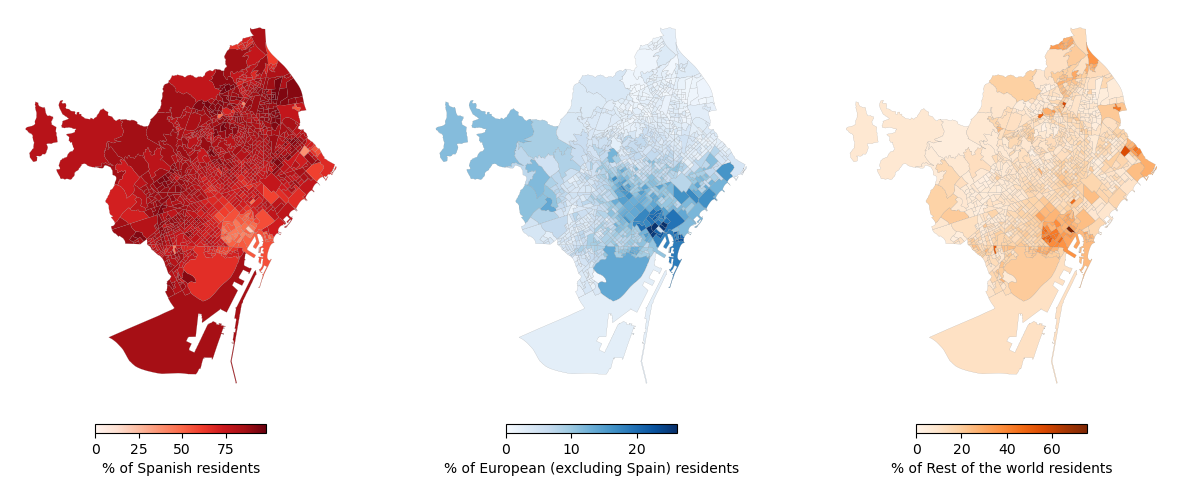

In [8]:
# Create a mapping from nationality to colour map for visualisation
cmap_dict = {
    "Spanish": "Reds",
    "European (excluding Spain)": "Blues",
    "Rest of the world": "Oranges",
}

# Plot a grid of maps to show the spatial distribution of each nationality group
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
nationalities = ["Spanish", "European (excluding Spain)", "Rest of the world"]
for ax, nationality in zip(axes.flatten(), nationalities):
    # Plot the proportion of each nationality in each census section
    join_bcn.plot(
        column=nationality,
        cmap=cmap_dict[nationality],  # Use a different colour map for each nationality
        norm=colors.Normalize(vmin=0),
        edgecolor="gray",  # Borderline colour
        linewidth=0.1,  # Borderline width
        ax=ax,
        legend=True,
        legend_kwds={
            "orientation": "horizontal",
            "shrink": 0.5,
            "pad": 0.02,
            "label": f"% of {nationality} residents",
        },
    )
    ax.set_axis_off()  # Hide axis for cleaner map presentation

The mean disposable income per capita in 2022 was estimated at €23,000. As shown in the map below, there are clear spatial differences in income levels across Barcelona. Areas with disposable incomes up to 1.8 times the average are concentrated in the western parts of the city, such as *Sarria*, *Sant Gervasi*, and *Les Tres Torres*. In contrast, lower income levels are more prevalent in the southern and northern areas, where disposable income is around half the city average.

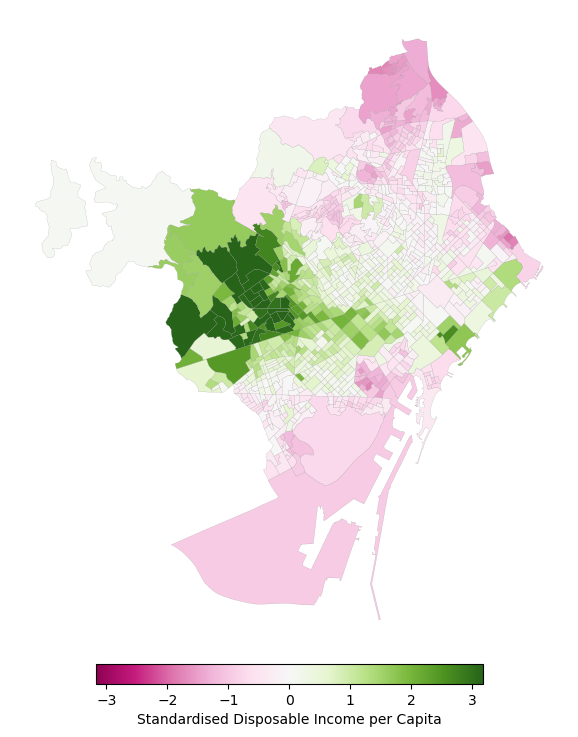

In [9]:
# Visualising the spatial distribution of disposable income ratio
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
join_bcn.plot(
    column="Income_std",
    ax=ax,
    cmap="PiYG",
    edgecolor="gray",  # Borderline color
    linewidth=0.1,  # Borderline width,
    legend=True,
    norm=colors.CenteredNorm(vcenter=0),
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.02,
        "label": "Standardised Disposable Income per Capita",
    },
)
ax.set_axis_off()

## Spatial autocorrelation in income and population by nationality 

The maps presented before may suggest that the spatial distributions of income and nationalities in Barcelona are not a result of a random process; that is, people with similar incomes tend to be close to each other, and people from other nationalities might tend to locate themselves in areas with more diverse populations.

To formally test this, spatial autocorrelation statistics were calculated for both disposable income and population. First, a spatial weights matrix was constructed using Queen contiguity, so each census area was assumed to be related to others that share a boundary or vertex, resulting in a median number of 6 neighbours per census area, with some having up to 23 neighbours and others as few as 2.

Second, the spatially lagged variables were computed using this weights matrix, and Moran's I statistics were calculated to assess the overall degree of spatial autocorrelation. As shown in the table below, both disposable income and population by nationality exhibit positive and statistically significant spatial autocorrelation (p < 0.001), with the strongest effects observed for disposable income (0.85) and the population of European nationals (0.83). Although the spatial autocorrelation for Spanish nationals (0.70) and non-European nationals (0.60) is slightly lower, they still show some degree of clustering. Moran plots for each variable are presented below, illustrating the positive relationships between each variable and its spatial lag.

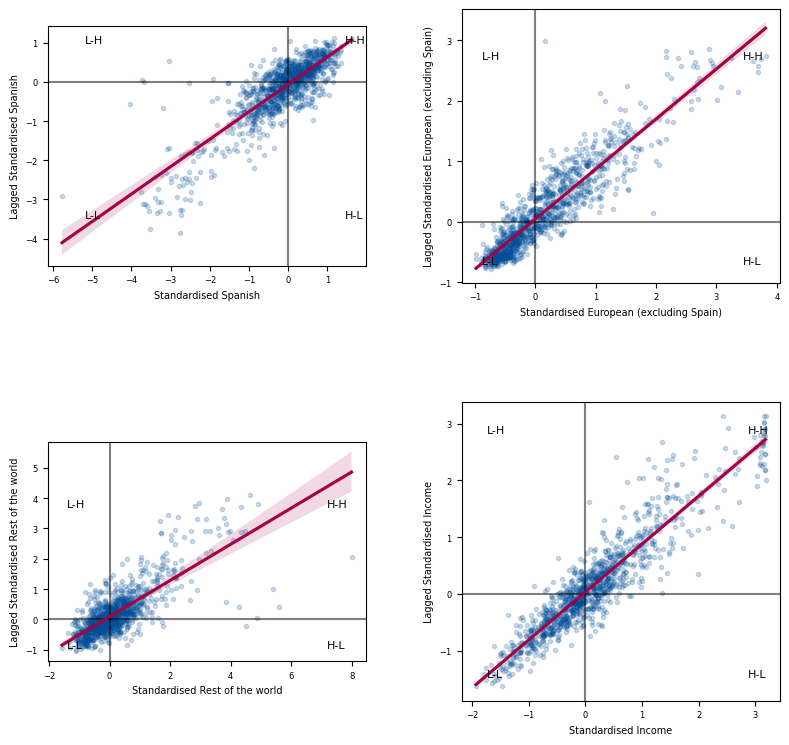

In [10]:
# Build a Queen contiguity spatial weights matrix (neighbours share boundary or vertex)
queen = graph.Graph.build_contiguity(join_bcn, rook=False)
# queen.summary()

# Transform the spatial weights matrix to row-standardised form
queen_row = queen.transform("R")

# Calculate spatial lag for each variable 
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]:
    join_bcn[col + "_std_lag"] = queen_row.lag(join_bcn[col + "_std"])

# Calculate global Moran's I statistic for each variable
moran_results = {}
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]:
    moran = esda.Moran(join_bcn[col + "_std"], queen_row)
    # Store both the I statistic and simulated p-value for assessing significance
    moran_results[col] = {"Moran's I": moran.I, "p-value": moran.p_sim}

# Create a 2x2 grid of Moran scatter plots to visualise spatial autocorrelation
f, ax = plt.subplots(2, 2, figsize=(8, 8))
cols = ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]
for col, subplot in zip(cols, ax.flatten()):
    # Set equal aspect ratio for Moran plot (standardised variable vs its spatial lag)
    subplot.set_aspect("equal")
    
    # Add reference lines at zero to divide the plot into quadrants
    subplot.axvline(0, c="black", alpha=0.5)
    subplot.axhline(0, c="black", alpha=0.5)
    
    # Label each quadrant: H-H (High-High), H-L (High-Low), L-H (Low-High), L-L (Low-Low)
    subplot.text(
        join_bcn[col + "_std"].max() * 0.9,
        join_bcn[col + "_std_lag"].max() * 0.9,
        "H-H",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].max() * 0.9,
        join_bcn[col + "_std_lag"].min() * 0.9,
        "H-L",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].min() * 0.9,
        join_bcn[col + "_std_lag"].max() * 0.9,
        "L-H",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].min() * 0.9,
        join_bcn[col + "_std_lag"].min() * 0.9,
        "L-L",
        fontsize=8,
    )
    
    # Create regression plot showing the relationship between variable and its spatial lag
    sns.regplot(
        x=col + "_std",
        y=col + "_std_lag",
        data=join_bcn,
        marker=".",
        color="#004d98",
        scatter_kws={"alpha": 0.2},
        line_kws=dict(color="#a50044"),
        ax=subplot,
    )
    subplot.set_xlabel("Standardised " + col, fontsize=7)
    subplot.set_ylabel("Lagged Standardised " + col, fontsize=7)

    subplot.tick_params(axis="both", which="major", labelsize=6)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.2)

To identify local clusters and outliers, Local Indicators of Spatial Association (LISAs) were computed for each variable. The resulting maps reveal distinct spatial patterns: a cluster of areas with a low proportion of Spanish nationals is found in the city centre, whilst clusters with predominantly Spanish populations are located in the west and north. European nationals form two main clusters—one with high proportions in the western part of the city, and another with low proportions in the north. Areas with a high proportion of non-European nationals are concentrated south of the city centre.

The western part of Barcelona stands out as a clear cluster of high disposable income, which also overlaps with areas where the proportion of non-European nationals is low. The north of the city, by contrast, shows a cluster of low disposable income where there is a mix of areas with high and low concentrations of non-European nationals.

Although there is some overlap between areas with high disposable income and those with a high proportion of European nationals, the level of aggregation used in this analysis limits the ability to draw definitive conclusions about the relationship between nationality and income. More detailed data of the characteristics of residents would be necessary to explore this relationship further.

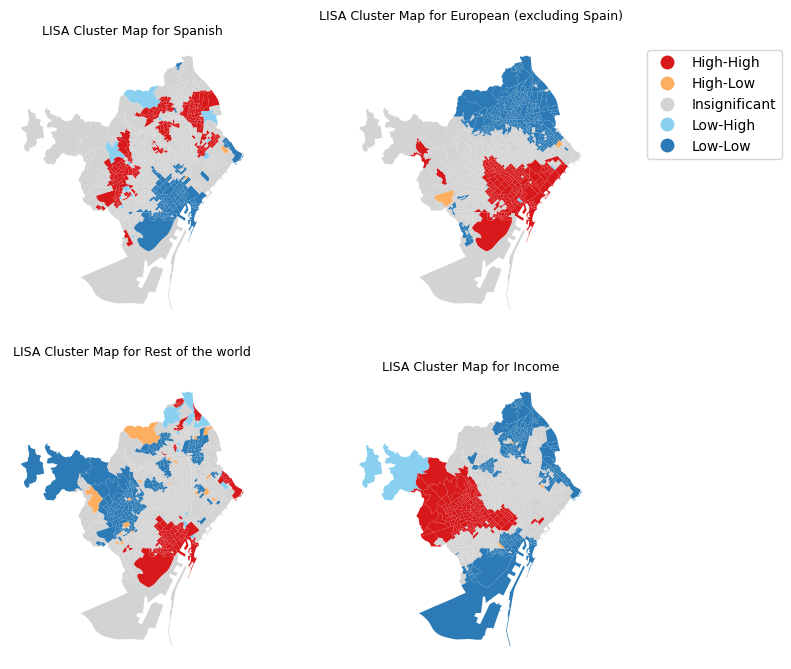

In [11]:
# Calculate and visualise Local Indicators of Spatial Association (LISA) cluster maps
cols = ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, col in zip(axes.flatten(), cols):
    # Compute local Moran's I for each observation (identifies local clusters and outliers)
    lisa = esda.Moran_Local(join_bcn[col + "_std"], queen_row)
    
    # Plot LISA results with cluster classification (H-H, L-L, H-L, L-H, or non-significant)
    lisa.plot(join_bcn, ax=ax, legend=True)
    
    ax.set_title(f"LISA Cluster Map for {col}", fontsize=9)
    ax.legend_.set_bbox_to_anchor((1.8, 1))
    ax.set_axis_off()
    
    # Remove legend from all subplots except the second one to avoid redundant legends
    if col != "European (excluding Spain)":
        ax.get_legend().remove()